In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║         TSA CAPSTONE 2026 — IIT Guwahati C&A Club                ║
# ║         Time Series Analysis on NSE Stocks                       ║
# ╚══════════════════════════════════════════════════════════════════╝

In [2]:
# Install required libraries
!pip install yfinance prophet statsmodels scikit-learn arch pandas matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 14.4 MB/s eta 0:00:00


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
from itertools import product
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
from prophet import Prophet

In [5]:
# TASK 1: STOCK UNIVERSE SELECTION

In [6]:
stocks = {
    "HDFCBANK.NS":  "Banking",
    "TCS.NS":       "IT",
    "SUNPHARMA.NS": "Pharma",
    "HINDUNILVR.NS":"FMCG",
    "MARUTI.NS":    "Auto"
}

In [7]:
tickers = list(stocks.keys())
print("Selected stocks:")
for t, s in stocks.items():
    print(f"  {t:20s} → {s}")

Selected stocks:
  HDFCBANK.NS          → Banking
  TCS.NS               → IT
  SUNPHARMA.NS         → Pharma
  HINDUNILVR.NS        → FMCG
  MARUTI.NS            → Auto


In [8]:
raw    = yf.download(tickers, start="2021-01-01", end="2025-12-31", interval="1d", auto_adjust=True)
prices = raw["Close"].copy()

print("Data shape:", prices.shape)
print("\nLast 5 rows:")
print(prices.tail())

[*********************100%***********************]  5 of 5 completed

Data shape: (1235, 5)

Last 5 rows:
Ticker      HDFCBANK.NS  HINDUNILVR.NS  MARUTI.NS  SUNPHARMA.NS       TCS.NS
Date                                                                        
2025-12-23   996.599976    2302.600098    16585.0   1744.567627  3250.902100
2025-12-24   997.200012    2282.199951    16703.0   1725.789673  3259.741455
2025-12-26   992.099976    2285.399902    16596.0   1708.402588  3221.437744
2025-12-29   991.700012    2293.300049    16542.0   1706.117310  3193.446533
2025-12-30   990.900024    2290.199951    16647.0   1709.098022  3188.830566


In [9]:
# TASK 2: DATA PREPROCESSING
prices = prices.ffill().bfill()
print("Missing values after fill:")
print(prices.isnull().sum())

train = prices[prices.index < "2025-07-01"]
test  = prices[prices.index >= "2025-07-01"]
print(f"\nTrain: {train.shape[0]} rows ({train.index[0].date()} to {train.index[-1].date()})")
print(f"Test:  {test.shape[0]}  rows ({test.index[0].date()} to {test.index[-1].date()})")

Missing values after fill:
Ticker
HDFCBANK.NS      0
HINDUNILVR.NS    0
MARUTI.NS        0
SUNPHARMA.NS     0
TCS.NS           0
dtype: int64

Train: 1110 rows (2021-01-01 to 2025-06-30)
Test:  125  rows (2025-07-01 to 2025-12-30)


In [10]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    status = " Stationary" if result[1] < 0.05 else " Non-stationary"
    print(f"  {name:20s}  ADF={result[0]:7.4f}  p={result[1]:.4f}  {status}")

print("── ADF Test on RAW prices ──")
for t in tickers:
    adf_test(train[t], t)

── ADF Test on RAW prices ──
  HDFCBANK.NS           ADF=-1.4168  p=0.5742   Non-stationary
  TCS.NS                ADF=-2.1757  p=0.2152   Non-stationary
  SUNPHARMA.NS          ADF=-0.6606  p=0.8567   Non-stationary
  HINDUNILVR.NS         ADF=-2.6978  p=0.0744   Non-stationary
  MARUTI.NS             ADF=-0.9747  p=0.7624   Non-stationary


In [11]:
prices_diff = prices.diff().dropna()
print("\n── ADF Test on DIFFERENCED prices ──")
for t in tickers:
    adf_test(prices_diff[t], t)


── ADF Test on DIFFERENCED prices ──
  HDFCBANK.NS           ADF=-14.0353  p=0.0000   Stationary
  TCS.NS                ADF=-34.2076  p=0.0000   Stationary
  SUNPHARMA.NS          ADF=-10.1058  p=0.0000   Stationary
  HINDUNILVR.NS         ADF=-35.1346  p=0.0000   Stationary
  MARUTI.NS             ADF=-24.9708  p=0.0000   Stationary


In [12]:

log_returns = np.log(prices / prices.shift(1)).dropna()
print("Log returns shape:", log_returns.shape)
print(log_returns.tail(3))

Log returns shape: (1234, 5)
Ticker      HDFCBANK.NS  HINDUNILVR.NS  MARUTI.NS  SUNPHARMA.NS    TCS.NS
Date                                                                     
2025-12-26    -0.005127       0.001401  -0.006427     -0.010126 -0.011820
2025-12-29    -0.000403       0.003451  -0.003259     -0.001339 -0.008727
2025-12-30    -0.000807      -0.001353   0.006327      0.001746 -0.001446


In [13]:

# TASK 3A: FORECASTING MODEL 1 — ARIMA

def best_arima_order(series, p_range=range(0,3), q_range=range(0,3), d=1):
    """Grid search over (p,q) with fixed d=1; returns order with lowest AIC."""
    best_aic   = np.inf
    best_order = (1, 1, 1)
    for p, q in product(p_range, q_range):
        try:
            aic = ARIMA(series, order=(p, d, q)).fit().aic
            if aic < best_aic:
                best_aic   = aic
                best_order = (p, d, q)
        except:
            continue
    return best_order

print("Finding best ARIMA orders (takes ~1-2 min)...")
best_orders = {}
for t in tickers:
    best_orders[t] = best_arima_order(train[t].dropna())
    print(f"  {t:20s} → best order = {best_orders[t]}")

Finding best ARIMA orders (takes ~1-2 min)...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  HDFCBANK.NS          → best order = (2, 1, 2)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  TCS.NS               → best order = (0, 1, 0)


...

  SUNPHARMA.NS         → best order = (2, 1, 2)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  HINDUNILVR.NS        → best order = (0, 1, 2)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  MARUTI.NS            → best order = (2, 1, 1)


In [14]:

arima_forecasts = {}
arima_metrics   = {}
arima_fits      = {}

for t in tickers:
    tr    = train[t].dropna()
    te    = test[t].dropna()
    order = best_orders[t]

    # Fit on training data
    fit = ARIMA(tr, order=order).fit()
    arima_fits[t] = fit

    # Forecast over test period length
    pred       = fit.forecast(steps=len(te))
    pred.index = te.index

    # Evaluation metrics
    mape    = np.mean(np.abs((te.values - pred.values) / te.values)) * 100
    rmse    = np.sqrt(np.mean((te.values - pred.values) ** 2))
    dir_acc = np.mean(
        np.sign(te.diff().dropna().values) ==
        np.sign(pred.diff().dropna().values)
    ) * 100

    arima_metrics[t] = {
        "MAPE":    round(mape, 2),
        "RMSE":    round(rmse, 2),
        "DirAcc%": round(dir_acc, 2)
    }

    # Forecast next 5 trading days beyond dataset
    arima_forecasts[t] = fit.forecast(steps=5).values

    print(f"\n{t}  order={order}")
    print(f"   MAPE={mape:.2f}%  RMSE={rmse:.2f}  DirAcc={dir_acc:.1f}%")
    print(f"   Next 5-day: {arima_forecasts[t].round(2)}")

print("\n ARIMA complete")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p


HDFCBANK.NS  order=(2, 1, 2)
   MAPE=1.44%  RMSE=19.50  DirAcc=47.6%
   Next 5-day: [996.41 997.54 997.88 996.41 997.91]

TCS.NS  order=(0, 1, 0)
   MAPE=10.56%  RMSE=338.70  DirAcc=0.0%
   Next 5-day: [3376.1 3376.1 3376.1 3376.1 3376.1]


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-p


SUNPHARMA.NS  order=(2, 1, 2)
   MAPE=3.29%  RMSE=68.89  DirAcc=50.8%
   Next 5-day: [1660.66 1660.39 1659.55 1660.72 1660.21]

HINDUNILVR.NS  order=(0, 1, 2)
   MAPE=7.60%  RMSE=217.02  DirAcc=0.8%
   Next 5-day: [2274.8  2275.63 2275.63 2275.63 2275.63]

MARUTI.NS  order=(2, 1, 1)
   MAPE=16.61%  RMSE=3061.31  DirAcc=54.0%
   Next 5-day: [12249.37 12257.51 12266.7  12274.21 12280.09]

 ARIMA complete


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa

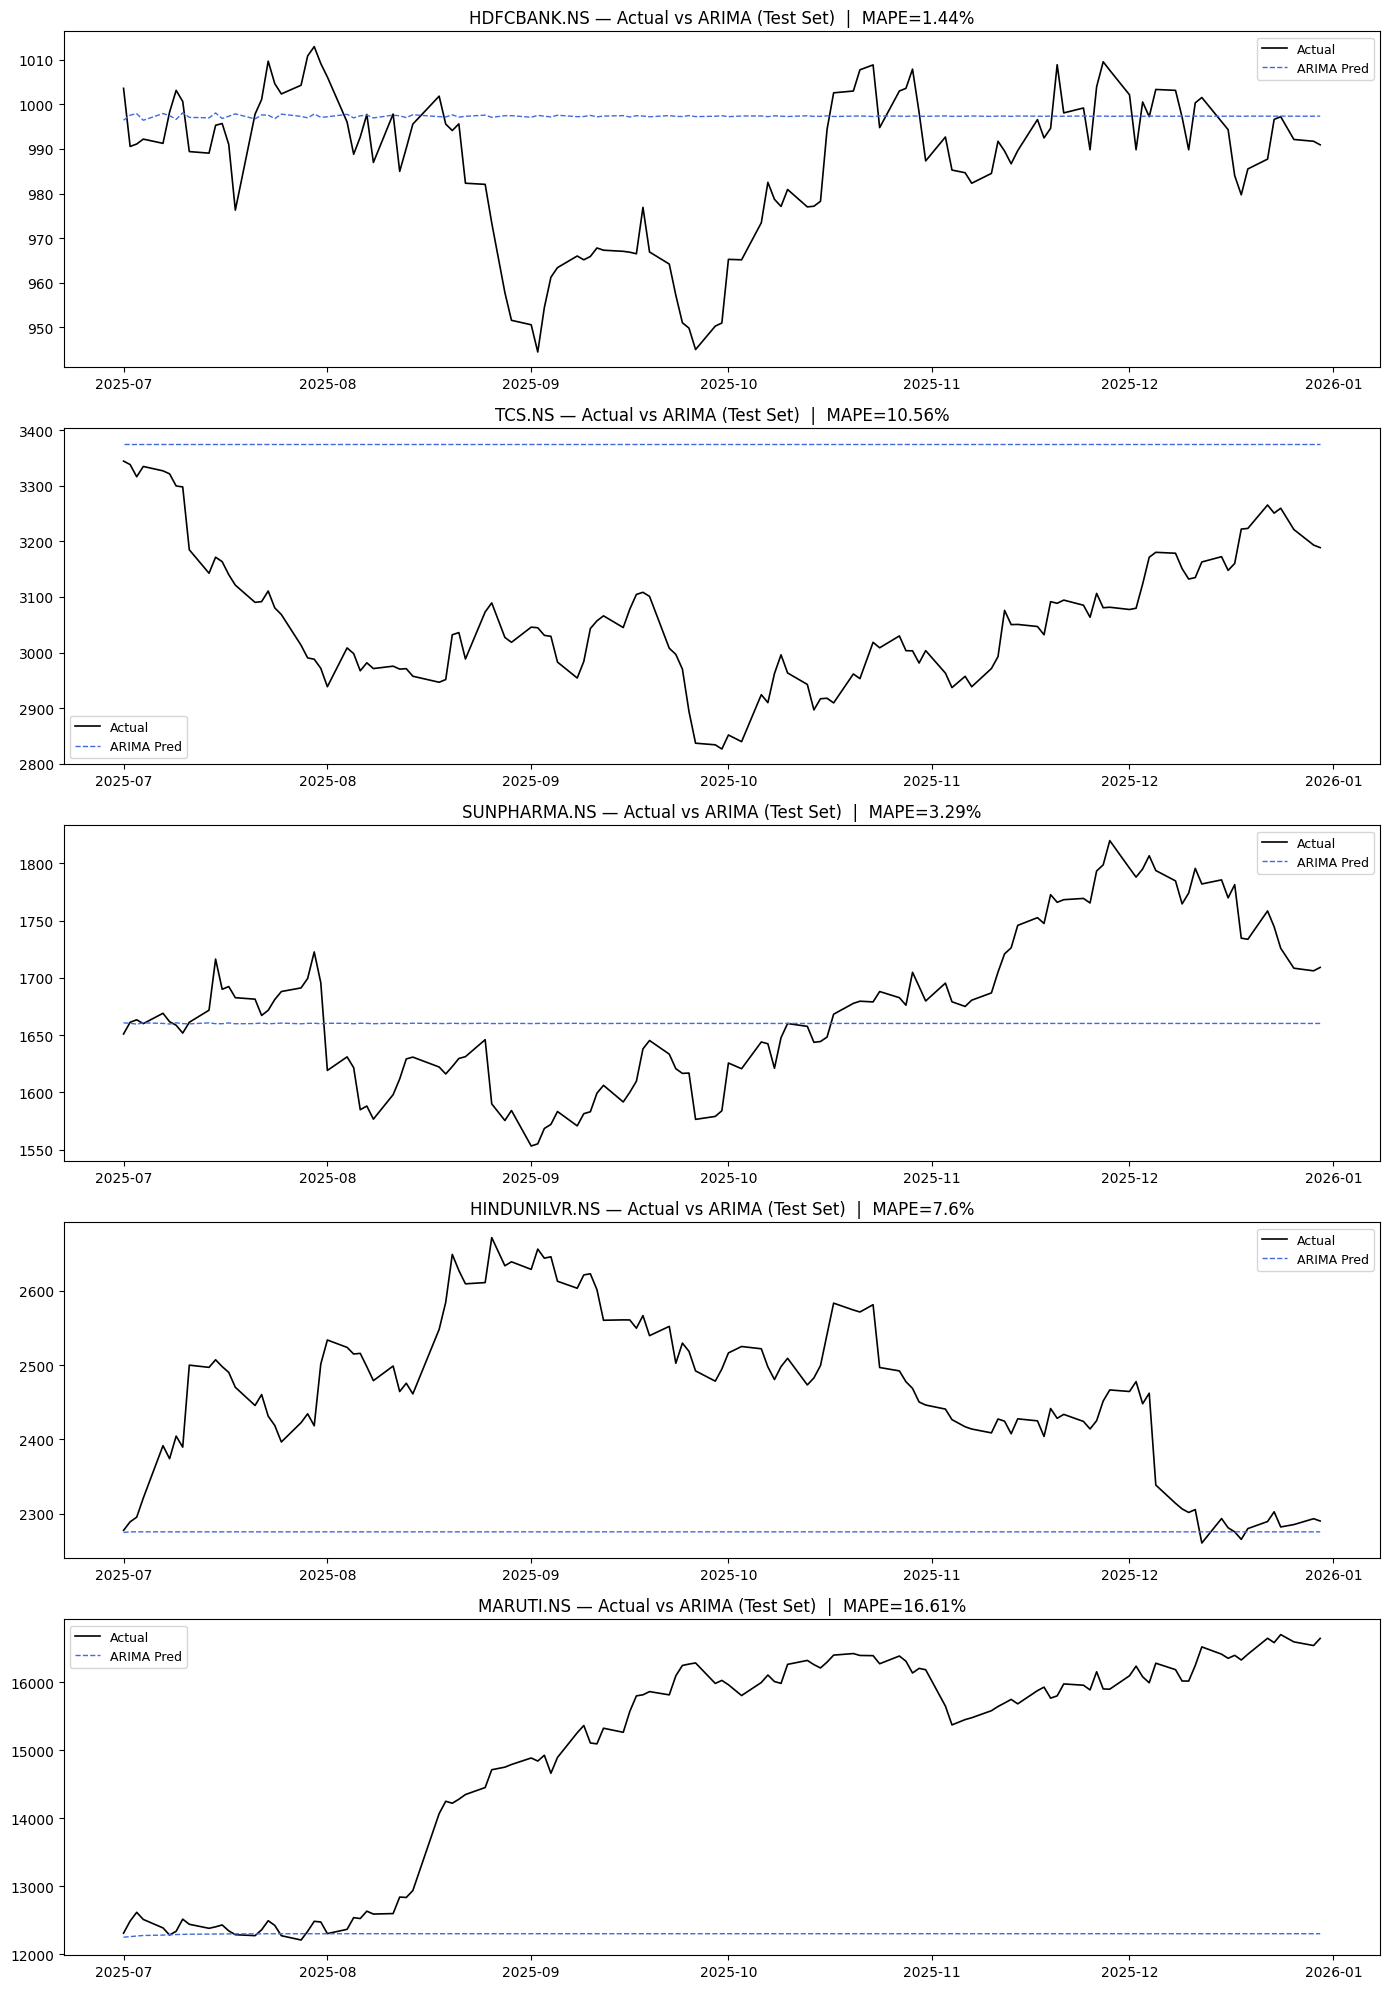

In [15]:

fig, axes = plt.subplots(len(tickers), 1, figsize=(14, 4*len(tickers)))

for i, t in enumerate(tickers):
    te   = test[t].dropna()
    pred = arima_fits[t].forecast(steps=len(te))
    pred.index = te.index

    axes[i].plot(te.index,   te.values,   label="Actual",       color="black",     linewidth=1.2)
    axes[i].plot(pred.index, pred.values, label="ARIMA Pred",   color="royalblue", linewidth=1, linestyle="--")
    axes[i].set_title(f"{t} — Actual vs ARIMA (Test Set)  |  MAPE={arima_metrics[t]['MAPE']}%")
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig("arima_predictions.png", dpi=150)
plt.show()

In [16]:

# TASK 3B: FORECASTING MODEL 2 — FACEBOOK PROPHET

prophet_forecasts = {}
prophet_metrics   = {}

for t in tickers:
    df_p = train[[t]].copy()
    df_p.index = df_p.index.tz_localize(None)
    df_p = df_p.reset_index()
    df_p.columns = ["ds", "y"]
    df_p["ds"] = pd.to_datetime(df_p["ds"])

    m = Prophet(
        daily_seasonality=False,
        yearly_seasonality=True,
        weekly_seasonality=True,
        changepoint_prior_scale=0.05
    )
    m.fit(df_p)

    future_df = m.make_future_dataframe(periods=len(test) + 5, freq="B")
    forecast  = m.predict(future_df)

    test_dates_clean = test.index.tz_localize(None)
    forecast_indexed = forecast.set_index("ds")
    pred_test = forecast_indexed["yhat"].reindex(test_dates_clean, method="nearest")
    te = test[t]

    mape    = np.mean(np.abs((te.values - pred_test.values) / te.values)) * 100
    rmse    = np.sqrt(np.mean((te.values - pred_test.values) ** 2))
    dir_acc = np.mean(
        np.sign(te.diff().dropna().values) ==
        np.sign(pred_test.diff().dropna().values)
    ) * 100

    prophet_metrics[t] = {
        "MAPE":    round(mape, 2),
        "RMSE":    round(rmse, 2),
        "DirAcc%": round(dir_acc, 2)
    }


    prophet_forecasts[t] = forecast["yhat"].iloc[-5:].values

    print(f"\n{t} Prophet")
    print(f"   MAPE={mape:.2f}%  RMSE={rmse:.2f}  DirAcc={dir_acc:.1f}%")
    print(f"   Next 5-day: {prophet_forecasts[t].round(2)}")

print("\n Prophet complete")


HDFCBANK.NS Prophet
   MAPE=3.71%  RMSE=42.20  DirAcc=55.6%
   Next 5-day: [1067.39 1067.21 1065.61 1064.82 1064.38]

TCS.NS Prophet
   MAPE=5.64%  RMSE=208.48  DirAcc=49.2%
   Next 5-day: [3070.6  3070.86 3067.53 3064.36 3059.  ]

SUNPHARMA.NS Prophet
   MAPE=9.03%  RMSE=169.74  DirAcc=58.9%
   Next 5-day: [1827.04 1831.2  1831.56 1833.94 1836.24]

HINDUNILVR.NS Prophet
   MAPE=3.31%  RMSE=100.68  DirAcc=54.0%
   Next 5-day: [2236.84 2238.95 2231.85 2232.86 2235.57]

MARUTI.NS Prophet
   MAPE=17.13%  RMSE=3183.24  DirAcc=51.6%
   Next 5-day: [11548.12 11560.4  11566.86 11570.6  11597.93]

 Prophet complete


In [17]:

last_date    = pd.Timestamp("2025-12-30")
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=5)

rows = []
for t in tickers:
    for i, date in enumerate(future_dates):
        rows.append({
            "Stock":    t,
            "Date":     date.strftime("%d %b %Y"),
            "ARIMA ₹":    round(arima_forecasts[t][i], 2),
            "Prophet ₹":  round(prophet_forecasts[t][i], 2),
            "Ensemble ₹": round((arima_forecasts[t][i] + prophet_forecasts[t][i]) / 2, 2),
        })

forecast_summary = pd.DataFrame(rows)
print("── 5-Day Ahead Forecasts ──")
print(forecast_summary.to_string(index=False))

── 5-Day Ahead Forecasts ──
        Stock        Date  ARIMA ₹  Prophet ₹  Ensemble ₹
  HDFCBANK.NS 31 Dec 2025   996.41    1067.39     1031.90
  HDFCBANK.NS 01 Jan 2026   997.54    1067.21     1032.38
  HDFCBANK.NS 02 Jan 2026   997.88    1065.61     1031.75
  HDFCBANK.NS 05 Jan 2026   996.41    1064.82     1030.61
  HDFCBANK.NS 06 Jan 2026   997.91    1064.38     1031.14
       TCS.NS 31 Dec 2025  3376.10    3070.60     3223.35
       TCS.NS 01 Jan 2026  3376.10    3070.86     3223.48
       TCS.NS 02 Jan 2026  3376.10    3067.53     3221.81
       TCS.NS 05 Jan 2026  3376.10    3064.36     3220.23
       TCS.NS 06 Jan 2026  3376.10    3059.00     3217.55
 SUNPHARMA.NS 31 Dec 2025  1660.66    1827.04     1743.85
 SUNPHARMA.NS 01 Jan 2026  1660.39    1831.20     1745.79
 SUNPHARMA.NS 02 Jan 2026  1659.55    1831.56     1745.55
 SUNPHARMA.NS 05 Jan 2026  1660.72    1833.94     1747.33
 SUNPHARMA.NS 06 Jan 2026  1660.21    1836.24     1748.23
HINDUNILVR.NS 31 Dec 2025  2274.80    2236.8

── Annualized Volatility (from log returns) ──
  HDFCBANK.NS           21.2%
  TCS.NS                20.7%
  SUNPHARMA.NS          20.9%
  HINDUNILVR.NS         20.1%
  MARUTI.NS             23.2%


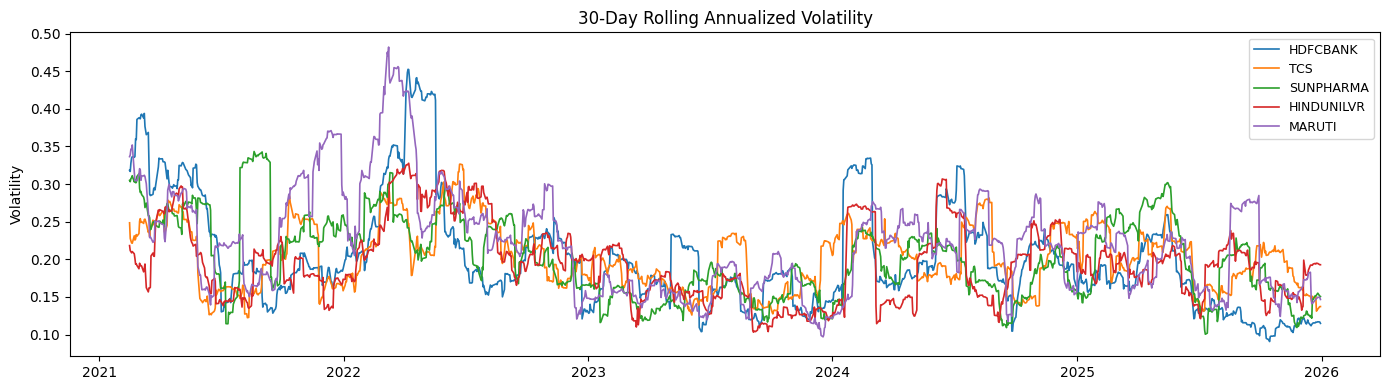

In [18]:

# TASK 4: VOLATILITY AND TREND ANALYSIS

annual_vol = log_returns.std() * np.sqrt(252)

print("── Annualized Volatility (from log returns) ──")
for t in tickers:
    print(f"  {t:20s}  {annual_vol[t]*100:.1f}%")


rolling_vol = log_returns.rolling(30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 4))
for t in tickers:
    ax.plot(rolling_vol.index, rolling_vol[t], label=t.replace(".NS",""), linewidth=1.2)
ax.set_title("30-Day Rolling Annualized Volatility")
ax.set_ylabel("Volatility")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("rolling_volatility.png", dpi=150)
plt.show()

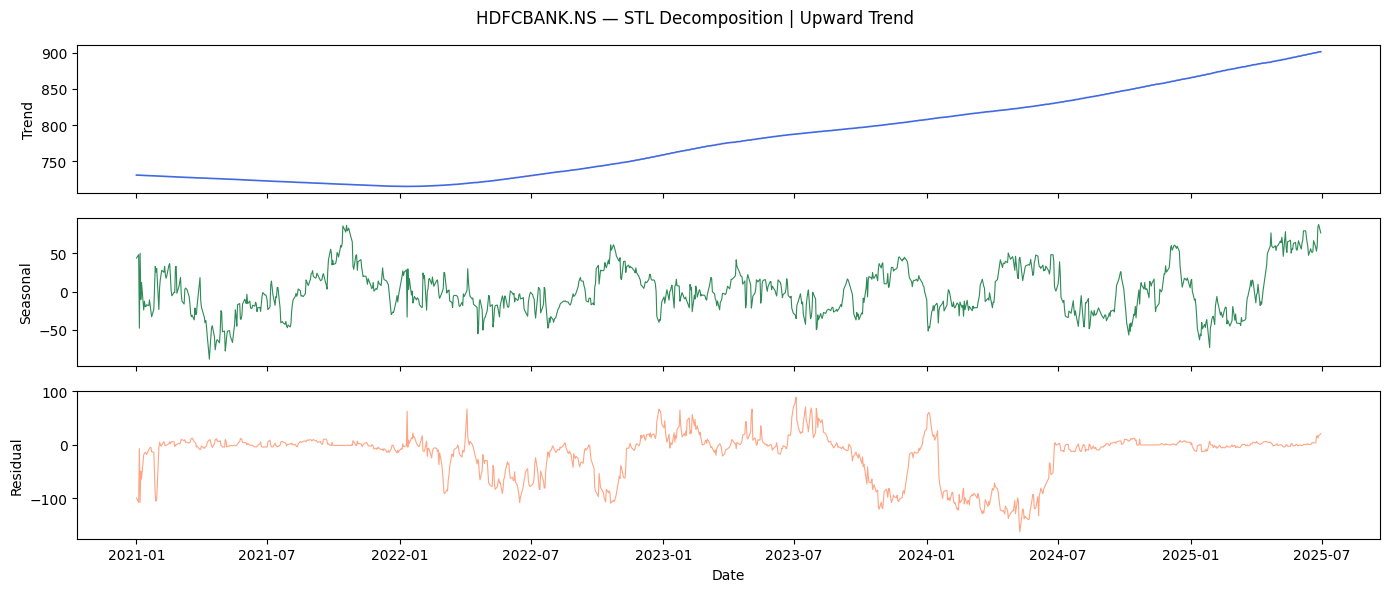

HDFCBANK.NS: slope=+8.60 → Upward


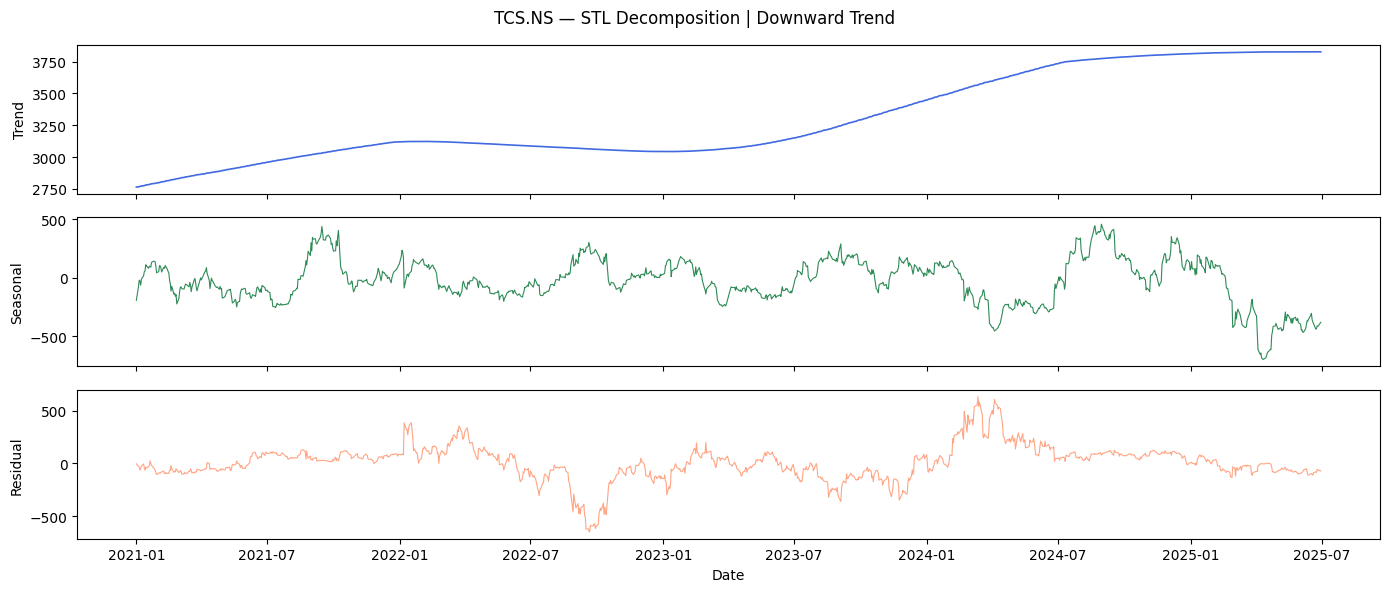

TCS.NS: slope=-0.24 → Downward


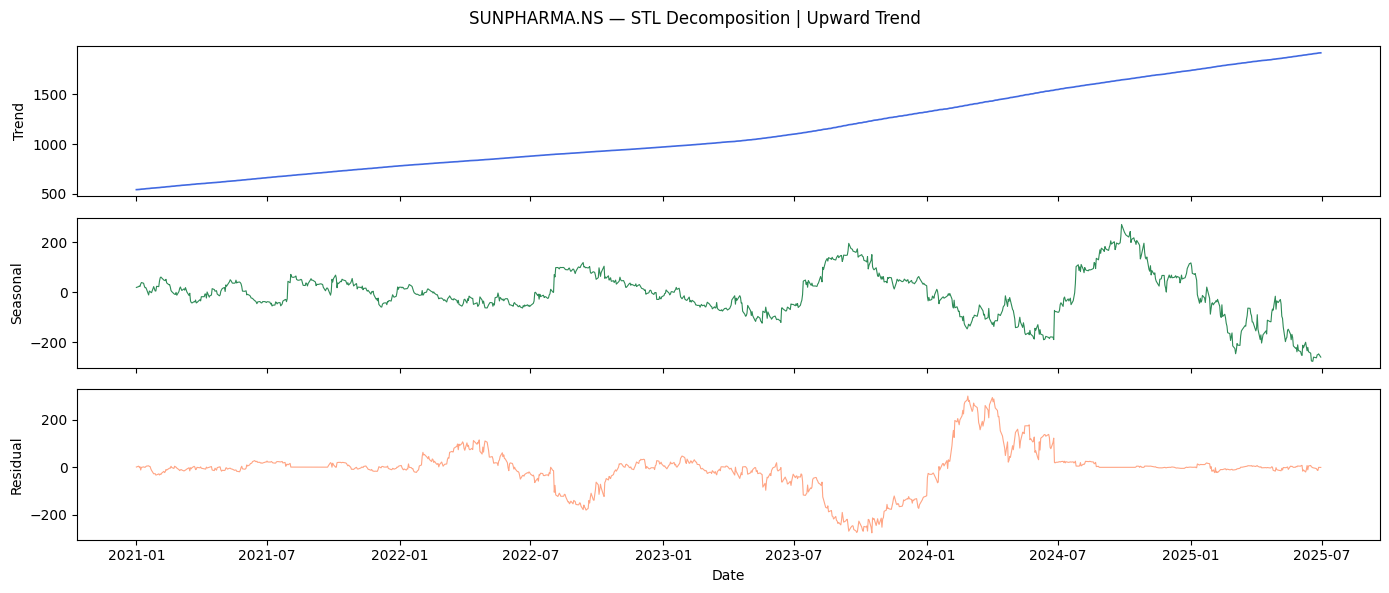

SUNPHARMA.NS: slope=+41.74 → Upward


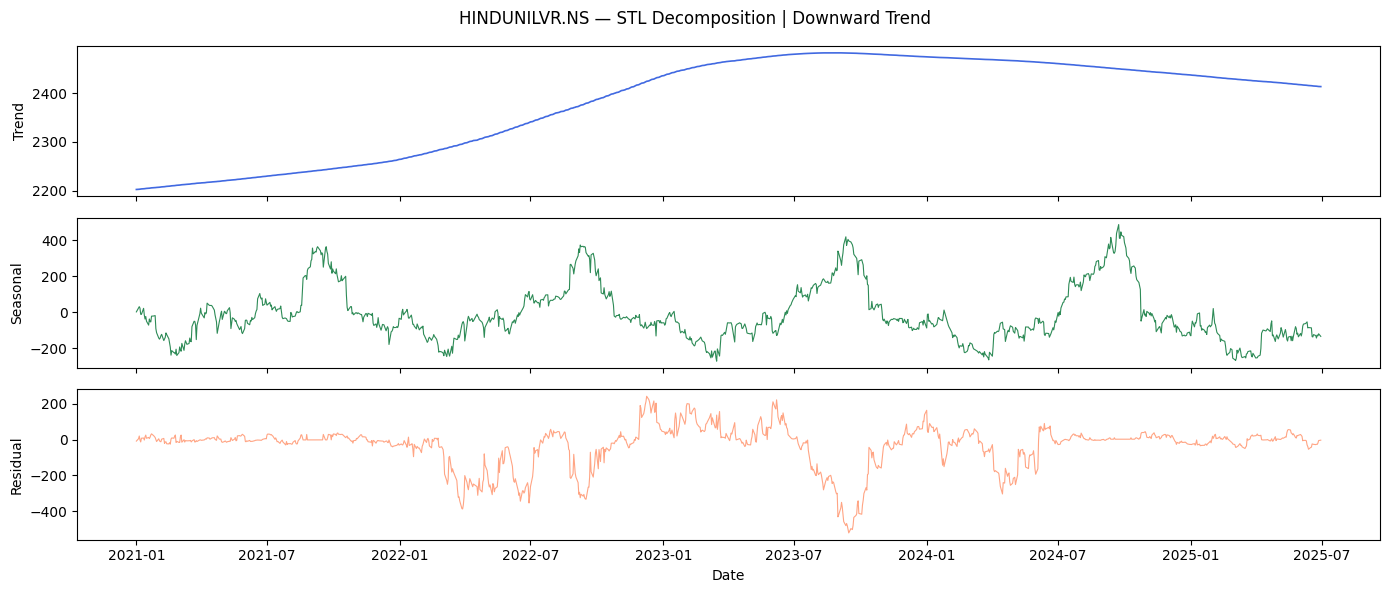

HINDUNILVR.NS: slope=-5.74 → Downward


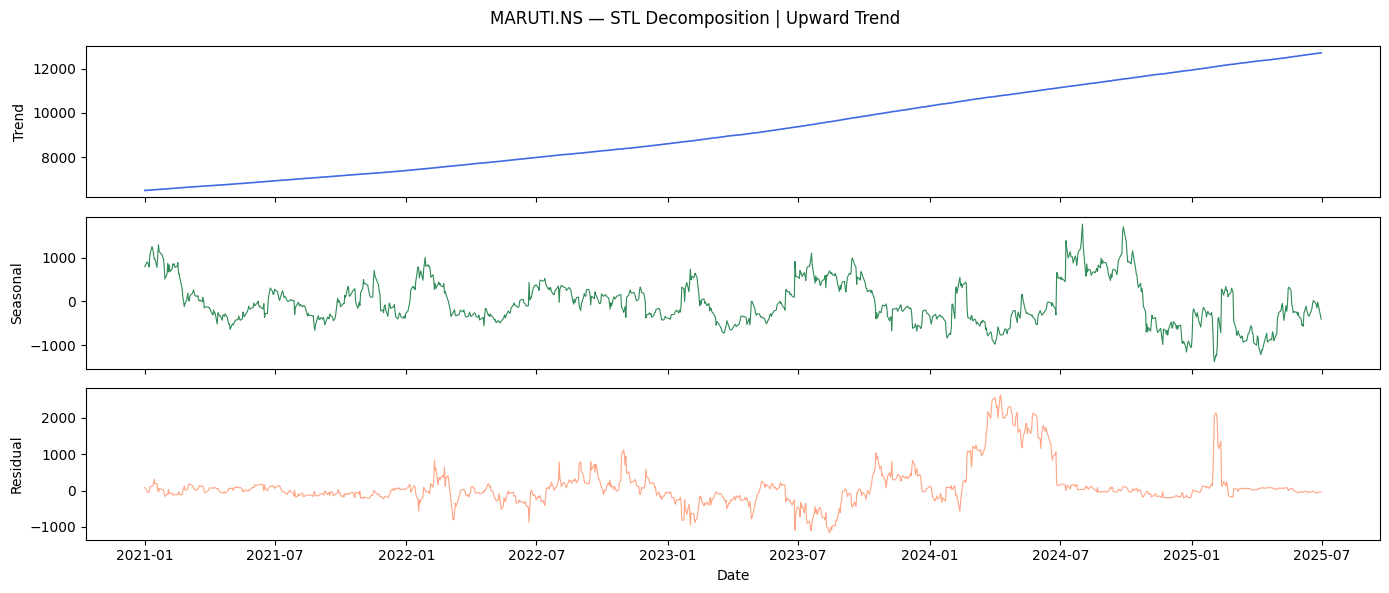

MARUTI.NS: slope=+184.63 → Upward


In [20]:

stl_trends = {}

for t in tickers:
    series = train[t].dropna()


    res = STL(series, period=252, robust=True).fit()

    trend_slope = res.trend.iloc[-1] - res.trend.iloc[-30]
    direction   = "Upward" if trend_slope > 0 else "Downward"
    stl_trends[t] = {"slope": trend_slope, "direction": direction}


    fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(res.trend,    color="royalblue", linewidth=1.2)
    axes[0].set_ylabel("Trend")
    axes[1].plot(res.seasonal, color="seagreen",  linewidth=0.8)
    axes[1].set_ylabel("Seasonal")
    axes[2].plot(res.resid,    color="coral",     linewidth=0.8, alpha=0.7)
    axes[2].set_ylabel("Residual")
    axes[2].set_xlabel("Date")
    fig.suptitle(f"{t} — STL Decomposition | {direction} Trend", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"stl_{t}.png", dpi=150)
    plt.show()
    print(f"{t}: slope={trend_slope:+.2f} → {direction}")

In [21]:

# TASK 5: PORTFOLIO CONSTRUCTION & CAPITAL ALLOCATION

last_price = prices.iloc[-1]
pred_return_A = {}
for t in tickers:
    ensemble_day5    = (arima_forecasts[t][-1] + prophet_forecasts[t][-1]) / 2
    pred_return_A[t] = (ensemble_day5 - last_price[t]) / last_price[t]

ret_A   = pd.Series(pred_return_A)
pos_ret = ret_A.clip(lower=0)


w_A = pos_ret / pos_ret.sum() if pos_ret.sum() > 0 \
      else pd.Series(1/len(tickers), index=tickers)

print("── Strategy A weights (forecast-guided) ──")
for t in tickers:
    print(f"  {t:20s}  predicted return={ret_A[t]*100:+.2f}%  weight={w_A[t]*100:.1f}%")

── Strategy A weights (forecast-guided) ──
  HDFCBANK.NS           predicted return=+4.06%  weight=56.0%
  TCS.NS                predicted return=+0.90%  weight=12.4%
  SUNPHARMA.NS          predicted return=+2.29%  weight=31.6%
  HINDUNILVR.NS         predicted return=-1.51%  weight=0.0%
  MARUTI.NS             predicted return=-28.28%  weight=0.0%


In [22]:

inv_vol = 1 / annual_vol
w_B     = inv_vol / inv_vol.sum()

print("── Strategy B weights (inverse volatility) ──")
for t in tickers:
    print(f"  {t:20s}  ann_vol={annual_vol[t]*100:.1f}%  weight={w_B[t]*100:.1f}%")

── Strategy B weights (inverse volatility) ──
  HDFCBANK.NS           ann_vol=21.2%  weight=19.9%
  TCS.NS                ann_vol=20.7%  weight=20.4%
  SUNPHARMA.NS          ann_vol=20.9%  weight=20.3%
  HINDUNILVR.NS         ann_vol=20.1%  weight=21.0%
  MARUTI.NS             ann_vol=23.2%  weight=18.3%


In [23]:

w_blend = (w_A * 0.5 + w_B * 0.5)
w_final = w_blend / w_blend.sum()

CAPITAL = 1_000_000

allocation = pd.DataFrame({
    "Sector":      [stocks[t] for t in tickers],
    "Pred 5d Ret": ret_A.map(lambda x: f"{x*100:+.2f}%"),
    "Ann Vol":     annual_vol.map(lambda x: f"{x*100:.1f}%"),
    "Trend":       [stl_trends[t]["direction"] for t in tickers],
    "Weight %":    (w_final * 100).round(2),
    "Alloc ₹":     (w_final * CAPITAL).round(0).astype(int),
    "Strategy":    "A(50%) + B(50%)"
}, index=tickers)

print("═"*72)
print("        FINAL PORTFOLIO ALLOCATION  (₹10,00,000)")
print("═"*72)
print(allocation.to_string())
print("═"*72)
print(f"Total allocated: ₹{int((w_final * CAPITAL).sum()):,}")

════════════════════════════════════════════════════════════════════════
        FINAL PORTFOLIO ALLOCATION  (₹10,00,000)
════════════════════════════════════════════════════════════════════════
                Sector Pred 5d Ret Ann Vol     Trend  Weight %  Alloc ₹         Strategy
HDFCBANK.NS    Banking      +4.06%   21.2%    Upward     37.97   379747  A(50%) + B(50%)
TCS.NS              IT      +0.90%   20.7%  Downward     16.42   164213  A(50%) + B(50%)
SUNPHARMA.NS    Pharma      +2.29%   20.9%    Upward     25.94   259448  A(50%) + B(50%)
HINDUNILVR.NS     FMCG      -1.51%   20.1%  Downward     10.52   105220  A(50%) + B(50%)
MARUTI.NS         Auto     -28.28%   23.2%    Upward      9.14    91372  A(50%) + B(50%)
════════════════════════════════════════════════════════════════════════
Total allocated: ₹1,000,000


In [24]:

# TASK 6: MODEL COMPARISON TABLE

comparison = pd.DataFrame({
    "ARIMA MAPE%":     {t: arima_metrics[t]["MAPE"]      for t in tickers},
    "ARIMA RMSE":      {t: arima_metrics[t]["RMSE"]      for t in tickers},
    "ARIMA DirAcc%":   {t: arima_metrics[t]["DirAcc%"]   for t in tickers},
    "Prophet MAPE%":   {t: prophet_metrics[t]["MAPE"]    for t in tickers},
    "Prophet RMSE":    {t: prophet_metrics[t]["RMSE"]    for t in tickers},
    "Prophet DirAcc%": {t: prophet_metrics[t]["DirAcc%"] for t in tickers},
})

comparison["Best Model"] = np.where(
    comparison["ARIMA MAPE%"] < comparison["Prophet MAPE%"],
    "ARIMA", "Prophet"
)

print("═"*72)
print("               MODEL COMPARISON TABLE")
print("═"*72)
print(comparison.to_string())
print("═"*72)
print(f"ARIMA wins:   {(comparison['Best Model']=='ARIMA').sum()}/5 stocks")
print(f"Prophet wins: {(comparison['Best Model']=='Prophet').sum()}/5 stocks")

════════════════════════════════════════════════════════════════════════
               MODEL COMPARISON TABLE
════════════════════════════════════════════════════════════════════════
               ARIMA MAPE%  ARIMA RMSE  ARIMA DirAcc%  Prophet MAPE%  Prophet RMSE  Prophet DirAcc% Best Model
HDFCBANK.NS           1.44       19.50          47.58           3.71         42.20            55.65      ARIMA
TCS.NS               10.56      338.70           0.00           5.64        208.48            49.19    Prophet
SUNPHARMA.NS          3.29       68.89          50.81           9.03        169.74            58.87      ARIMA
HINDUNILVR.NS         7.60      217.02           0.81           3.31        100.68            54.03    Prophet
MARUTI.NS            16.61     3061.31          54.03          17.13       3183.24            51.61      ARIMA
════════════════════════════════════════════════════════════════════════
ARIMA wins:   3/5 stocks
Prophet wins: 2/5 stocks


In [25]:

# TASK 7: VIRTUAL TRADING ON STOCKGRO

print("── StockGro Execution Summary ──")
print(f"Platform   : StockGro (NSE live data)")
print(f"Capital    : ₹10,00,000")
print(f"Event      : Portfolio – Time Series Analysis 2026")
print()
for t in tickers:
    amt = int(w_final[t] * CAPITAL)
    print(f"  BUY  {t:20s}  ₹{amt:>8,}  ({w_final[t]*100:.1f}%)")

── StockGro Execution Summary ──
Platform   : StockGro (NSE live data)
Capital    : ₹10,00,000
Event      : Portfolio – Time Series Analysis 2026

  BUY  HDFCBANK.NS           ₹ 379,747  (38.0%)
  BUY  TCS.NS                ₹ 164,212  (16.4%)
  BUY  SUNPHARMA.NS          ₹ 259,448  (25.9%)
  BUY  HINDUNILVR.NS         ₹ 105,219  (10.5%)
  BUY  MARUTI.NS             ₹  91,372  (9.1%)


In [26]:

# TASK 8: PERFORMANCE TRACKING — PREDICTED vs ACTUAL
actual_data = yf.download(
    tickers,
    start="2025-12-31",
    end="2026-01-07",
    interval="1d",
    auto_adjust=True
)["Close"].dropna(how="all")

print("── Actual closing prices (Jan 2026) ──")
print(actual_data.to_string())

actual_dates = actual_data.index[:2]
day1_date    = actual_dates[0]
day2_date    = actual_dates[1]
print(f"\nDay 1 → {day1_date.date()}  |  Day 2 → {day2_date.date()}")

[*********************100%***********************]  5 of 5 completed

── Actual closing prices (Jan 2026) ──
Ticker      HDFCBANK.NS  HINDUNILVR.NS  MARUTI.NS  SUNPHARMA.NS       TCS.NS
Date                                                                        
2025-12-31   991.200012    2315.899902    16697.0   1708.601196  3148.955322
2026-01-01   991.150024    2323.000000    16708.0   1709.992188  3169.776855
2026-01-02  1001.599976    2348.000000    16960.0   1716.847656  3192.660889
2026-01-05   977.500000    2384.100098    17155.0   1717.741943  3158.678711
2026-01-06   962.200012    2424.699951    17292.0   1748.839844  3197.669922

Day 1 → 2025-12-31  |  Day 2 → 2026-01-01


In [27]:

rows = []
for t in tickers:
    pred_d1 = (arima_forecasts[t][0] + prophet_forecasts[t][0]) / 2
    pred_d2 = (arima_forecasts[t][1] + prophet_forecasts[t][1]) / 2
    act_d1  = float(actual_data.loc[day1_date, t])
    act_d2  = float(actual_data.loc[day2_date, t])

    err_d1      = abs(pred_d1 - act_d1) / act_d1 * 100
    err_d2      = abs(pred_d2 - act_d2) / act_d2 * 100
    dir_correct = "correct" if np.sign(pred_d2 - pred_d1) == np.sign(act_d2 - act_d1) else "wrong"

    rows.append({
        "Stock":       t.replace(".NS", ""),
        "Pred D1 ₹":   round(pred_d1, 2),
        "Act D1 ₹":    round(act_d1,  2),
        "Err D1 %":    round(err_d1,  2),
        "Pred D2 ₹":   round(pred_d2, 2),
        "Act D2 ₹":    round(act_d2,  2),
        "Err D2 %":    round(err_d2,  2),
        "Dir Correct": dir_correct,
    })

results = pd.DataFrame(rows).set_index("Stock")
print("\n" + "═"*80)
print("       TASK 8 — PREDICTED vs ACTUAL  (Ensemble Forecast)")
print("═"*80)
print(results.to_string())
print("═"*80)
print(f"Avg error Day1 : {results['Err D1 %'].mean():.2f}%")
print(f"Avg error Day2 : {results['Err D2 %'].mean():.2f}%")
print(f"Directional acc: {(results['Dir Correct']=='✅').sum()}/5 stocks correct")


════════════════════════════════════════════════════════════════════════════════
       TASK 8 — PREDICTED vs ACTUAL  (Ensemble Forecast)
════════════════════════════════════════════════════════════════════════════════
            Pred D1 ₹  Act D1 ₹  Err D1 %  Pred D2 ₹  Act D2 ₹  Err D2 % Dir Correct
Stock                                                                               
HDFCBANK      1031.90    991.20      4.11    1032.38    991.15      4.16       wrong
TCS           3223.35   3148.96      2.36    3223.48   3169.78      1.69     correct
SUNPHARMA     1743.85   1708.60      2.06    1745.79   1709.99      2.09     correct
HINDUNILVR    2255.82   2315.90      2.59    2257.29   2323.00      2.83     correct
MARUTI       11898.75  16697.00     28.74   11908.95  16708.00     28.72     correct
════════════════════════════════════════════════════════════════════════════════
Avg error Day1 : 7.97%
Avg error Day2 : 7.90%
Directional acc: 0/5 stocks correct


In [28]:

print("── Stock-level Returns ──")
port_return = 0
for t in tickers:
    act_d1      = float(actual_data.loc[day1_date, t])
    act_d2      = float(actual_data.loc[day2_date, t])
    ret         = (act_d2 - act_d1) / act_d1 * 100
    contribution = w_final[t] * ret
    port_return += contribution
    print(f"  {t:20s}  wt={w_final[t]*100:.1f}%  ret={ret:+.2f}%  contrib={contribution:+.3f}%")

pnl = port_return / 100 * CAPITAL
print(f"\n  Total 2-day portfolio return : {port_return:+.4f}%")
print(f"  P&L on ₹10,00,000           : ₹{pnl:+,.0f}")

── Stock-level Returns ──
  HDFCBANK.NS           wt=38.0%  ret=-0.01%  contrib=-0.002%
  TCS.NS                wt=16.4%  ret=+0.66%  contrib=+0.109%
  SUNPHARMA.NS          wt=25.9%  ret=+0.08%  contrib=+0.021%
  HINDUNILVR.NS         wt=10.5%  ret=+0.31%  contrib=+0.032%
  MARUTI.NS             wt=9.1%  ret=+0.07%  contrib=+0.006%

  Total 2-day portfolio return : +0.1661%
  P&L on ₹10,00,000           : ₹+1,661


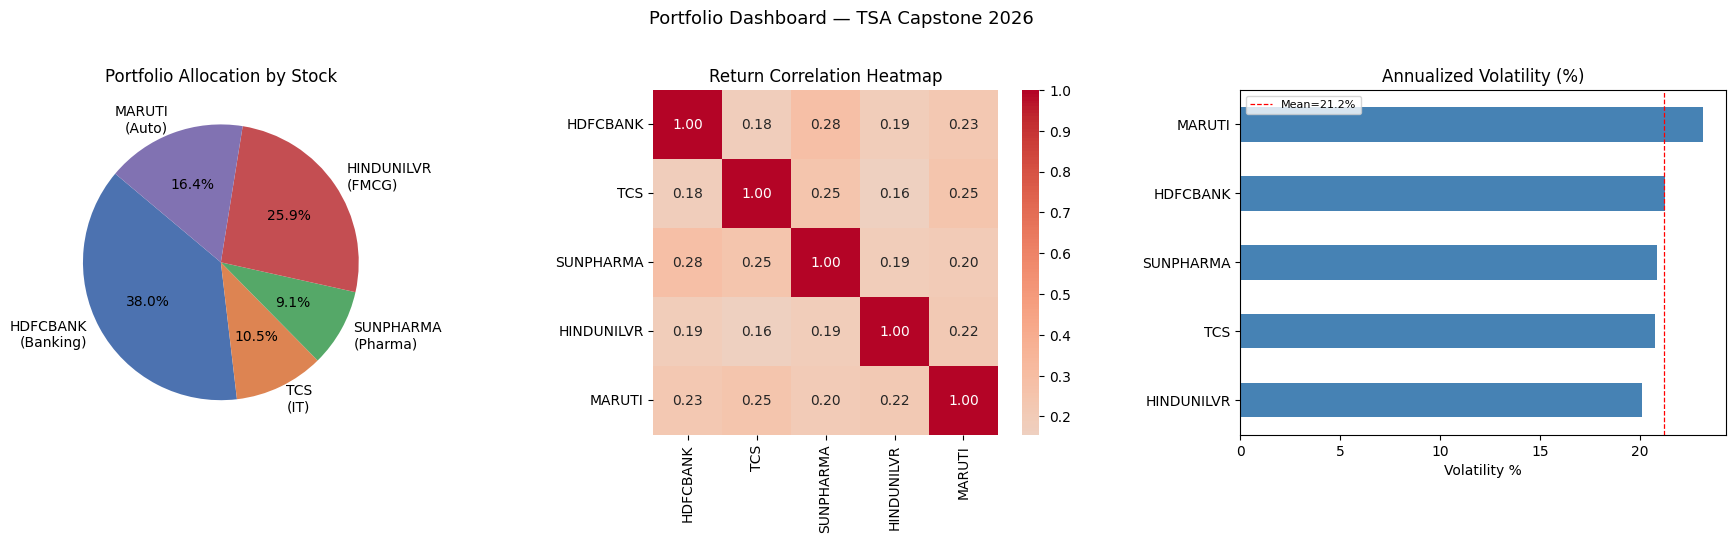

Dashboard saved → dashboard.png


In [29]:

# BONUS: VISUAL DASHBOARD

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Portfolio allocation pie chart
labels = [f"{t.replace('.NS','')}\n({stocks[t]})" for t in tickers]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
axes[0].pie(
    w_final,
    labels=labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors
)
axes[0].set_title("Portfolio Allocation by Stock")

# Chart 2: Return correlation heatmap
corr = log_returns.corr()
corr.index   = [t.replace(".NS","") for t in tickers]
corr.columns = [t.replace(".NS","") for t in tickers]
sns.heatmap(
    corr, annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    ax=axes[1], square=True
)
axes[1].set_title("Return Correlation Heatmap")

# Chart 3: Annualized volatility bar chart
vol_pct = (annual_vol * 100).sort_values()
vol_pct.index = [t.replace(".NS","") for t in vol_pct.index]
vol_pct.plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title("Annualized Volatility (%)")
axes[2].set_xlabel("Volatility %")
axes[2].axvline(vol_pct.mean(), color="red", linestyle="--",
                linewidth=0.9, label=f"Mean={vol_pct.mean():.1f}%")
axes[2].legend(fontsize=8)

plt.suptitle("Portfolio Dashboard — TSA Capstone 2026", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved → dashboard.png")

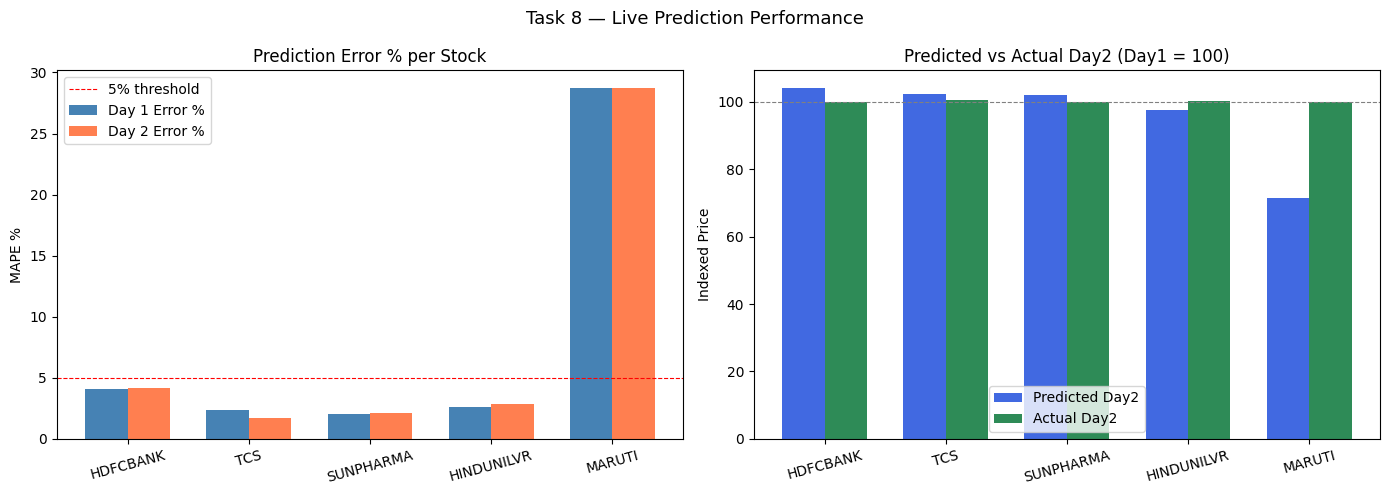

 Task 8 chart saved → task8_comparison.png


In [30]:
# Task 8 Visualization: Prediction error + indexed price comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stock_labels = [t.replace(".NS","") for t in tickers]
x = np.arange(len(tickers))
w = 0.35


axes[0].bar(x - w/2, results["Err D1 %"].values, w,
            label="Day 1 Error %", color="steelblue")
axes[0].bar(x + w/2, results["Err D2 %"].values, w,
            label="Day 2 Error %", color="coral")
axes[0].axhline(5, color="red", linestyle="--",
                linewidth=0.8, label="5% threshold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(stock_labels, rotation=15)
axes[0].set_title("Prediction Error % per Stock")
axes[0].set_ylabel("MAPE %")
axes[0].legend()


base   = {t: float(actual_data.loc[day1_date, t]) for t in tickers}
pred_n = [results.loc[t.replace(".NS",""), "Pred D2 ₹"] / base[t] * 100 for t in tickers]
act_n  = [results.loc[t.replace(".NS",""), "Act D2 ₹"]  / base[t] * 100 for t in tickers]

axes[1].bar(x - w/2, pred_n, w, label="Predicted Day2", color="royalblue")
axes[1].bar(x + w/2, act_n,  w, label="Actual Day2",    color="seagreen")
axes[1].axhline(100, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(stock_labels, rotation=15)
axes[1].set_title("Predicted vs Actual Day2 (Day1 = 100)")
axes[1].set_ylabel("Indexed Price")
axes[1].legend()

plt.suptitle("Task 8 — Live Prediction Performance", fontsize=13)
plt.tight_layout()
plt.savefig("task8_comparison.png", dpi=150)
plt.show()
print(" Task 8 chart saved → task8_comparison.png")

In [ ]:
#  Final checklist
print("═"*50)
print("  SUBMISSION CHECKLIST")
print("═"*50)
items = [
    ("Task 1", "Stock universe selected & justified"),
    ("Task 2", "Missing values handled, ADF tested, train/test split"),
    ("Task 3", "ARIMA + Prophet fitted, 5-day forecasts generated"),
    ("Task 4", "Log returns, volatility, STL decomposition done"),
    ("Task 5", "Portfolio allocated (Strategy A + B blend)"),
    ("Task 6", "Model comparison table generated"),
    ("Task 7", "StockGro trades executed (manual)"),
    ("Task 8", "Predicted vs actual comparison done"),
    ("Bonus",  "Dashboard saved as dashboard.png"),
]
for task, desc in items:
    print(f"  ✅  [{task}]  {desc}")
print("═"*50)
print("  All done! Save this notebook as .ipynb and submit.")
print("═"*50)